# Phase1: Data Engineering

# Packages

In [4]:
pip install refinitiv.data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 3.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.0
    Uninstalling pandas-3.0.0:
      Successfully uninstalled pandas-3.0.0
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install Alphalens

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import refinitiv.data as rd
from refinitiv.data.content import historical_pricing
from math import sqrt

# 1. Data Fetching

In [7]:
rd.open_session()

<refinitiv.data.session.Definition object at 0x12e422cd0 {name='workspace'}>

## 1.1 Price Volume

In [8]:
close_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.PriceClose"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [9]:
close_df.tail()

Price Close,ENR1n.DE,ENI.MI,ENEI.MI,RACE.MI,DHLn.DE,ALVG.DE,IBE.MC,DTEGn.DE,SASY.PA,LVMH.PA,...,DB1Gn.DE,INGA.AS,PRX.AS,OREP.PA,TTEF.PA,ABI.BR,AXAF.PA,ASML.AS,BAYGn.DE,CRDI.MI
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,120.75,15.96,8.769,319.9,46.59,391.0,17.98364,27.48,82.22,627.3,...,223.8,23.925,52.72,362.55,55.85,54.26,41.11,903.2,35.94,69.94
2025-12-24,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,18.042829,<NA>,81.61,632.1,...,<NA>,23.935,52.38,363.8,55.61,54.38,41.14,899.0,<NA>,<NA>
2025-12-29,120.6,15.976,8.814,318.9,46.66,388.8,18.082288,27.7,82.24,633.2,...,224.2,23.78,52.64,365.3,55.95,54.88,40.86,906.8,36.415,69.33
2025-12-30,120.4,16.14,8.877,318.7,46.73,390.5,18.205599,27.66,83.0,639.3,...,223.7,24.025,52.84,366.95,56.4,54.92,41.14,918.4,37.01,70.92
2025-12-31,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,18.215464,<NA>,82.72,645.0,...,<NA>,24.01,52.85,366.6,55.59,54.9,40.96,921.4,<NA>,<NA>


In [10]:
returns_df = close_df.pct_change()
returns_df = returns_df.dropna(how="all")
returns_df.tail()

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_67414/3585842263.py:1:FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


Price Close,ENR1n.DE,ENI.MI,ENEI.MI,RACE.MI,DHLn.DE,ALVG.DE,IBE.MC,DTEGn.DE,SASY.PA,LVMH.PA,...,DB1Gn.DE,INGA.AS,PRX.AS,OREP.PA,TTEF.PA,ABI.BR,AXAF.PA,ASML.AS,BAYGn.DE,CRDI.MI
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,0.012579,-0.005731,0.007584,0.0,0.000215,0.001537,0.008575,0.00292,0.007845,-0.000637,...,0.008562,0.000209,-0.00246,-0.010643,-0.001609,0.002587,0.000243,0.008036,0.013679,0.001432
2025-12-24,0.0,0.0,0.0,0.0,0.0,0.0,0.003291,0.0,-0.007419,0.007652,...,0.0,0.000418,-0.006449,0.003448,-0.004297,0.002212,0.00073,-0.00465,0.0,0.0
2025-12-29,-0.001242,0.001003,0.005132,-0.003126,0.001502,-0.005627,0.002187,0.008006,0.00772,0.00174,...,0.001787,-0.006476,0.004964,0.004123,0.006114,0.009195,-0.006806,0.008676,0.013216,-0.008722
2025-12-30,-0.001658,0.010265,0.007148,-0.000627,0.0015,0.004372,0.006819,-0.001444,0.009241,0.009634,...,-0.00223,0.010303,0.003799,0.004517,0.008043,0.000729,0.006853,0.012792,0.016339,0.022934
2025-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.000542,0.0,-0.003373,0.008916,...,0.0,-0.000624,0.000189,-0.000954,-0.014362,-0.000364,-0.004375,0.003267,0.0,0.0


In [11]:
open_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.PriceOpen"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [12]:
open_df.tail()

Price Open,ENR1n.DE,ENI.MI,ENEI.MI,RACE.MI,DHLn.DE,ALVG.DE,IBE.MC,DTEGn.DE,SASY.PA,LVMH.PA,...,DB1Gn.DE,INGA.AS,PRX.AS,OREP.PA,TTEF.PA,ABI.BR,AXAF.PA,ASML.AS,BAYGn.DE,CRDI.MI
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,119.5,16.044,8.73,319.6,46.7,391.4,17.830734,27.47,81.6,627.7,...,222.2,23.93,52.83,366.55,55.86,53.96,41.1,895.0,35.455,69.63
2025-12-24,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,17.954045,<NA>,82.16,629.7,...,<NA>,23.88,53.03,362.35,56.1,53.98,40.8,897.0,<NA>,<NA>
2025-12-29,121.7,16.046,8.77,321.0,46.6,392.4,17.993505,27.5,82.07,632.9,...,225.5,24.04,52.58,365.0,55.81,54.26,41.13,908.1,35.965,70.09
2025-12-30,120.0,16.01,8.786,318.9,46.66,389.3,18.057626,27.77,82.48,631.1,...,224.6,23.825,52.76,364.05,56.03,54.4,40.8,908.4,36.335,69.35
2025-12-31,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,18.240126,<NA>,82.99,636.9,...,<NA>,23.93,53.14,365.75,55.59,54.94,41.21,909.9,<NA>,<NA>


In [13]:
high_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.PriceHigh"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in

In [14]:
low_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.PriceLow"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in

In [15]:
volume_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.Volume"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [16]:
volume_df.tail()

Volume,ENI.MI,RACE.MI,DHLn.DE,SIEGn.DE,DB1Gn.DE,INGA.AS,BAYGn.DE,CRDI.MI,BBVA.MC,DBKGn.DE,...,AIRP.PA,SAN.MC,IFXGn.DE,MBGn.DE,AD.AS,AIR.PA,ENR1n.DE,LVMH.PA,SASY.PA,ENEI.MI
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,5723228,292349,1050011,485809,216374,5525319,1728776,3099235,7068285,3247417,...,593574,20022685,1729190,885825,781846,489426,1132225,161944,1998123,11087509
2025-12-24,<NA>,<NA>,<NA>,<NA>,<NA>,1052108,<NA>,<NA>,2189502,<NA>,...,135147,4500182,<NA>,<NA>,169944,108258,<NA>,55878,535668,<NA>
2025-12-29,6624648,247870,1113773,543337,216042,6489615,2280958,3076414,8263136,4521478,...,525197,23050496,2354027,1643067,1372155,585469,1259134,199081,1696247,12565435
2025-12-30,8041391,246455,712839,424839,142849,4480289,1642128,5334859,6130969,2011178,...,408724,16870811,2024272,1017759,1283378,608927,691887,179559,1327869,15277527
2025-12-31,<NA>,<NA>,<NA>,<NA>,<NA>,1736994,<NA>,<NA>,3738507,<NA>,...,238734,7146353,<NA>,<NA>,623854,199465,<NA>,105713,599236,<NA>


In [17]:
# vwap Proxy
vwap_df = (close_df + open_df + high_df + low_df)/4

## 1.2 Fundamentals

In [18]:
revenue_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.Revenue"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [19]:
gross_profit_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.GrossProfit"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [20]:
EV_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.EV"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [21]:
EBIT_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.EBIT"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instea

In [22]:
EBITDA_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.EBITDA"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [23]:
PE_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.PE"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [24]:
WACC_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.WACC"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [25]:
cap_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.CompanyMarketCap"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

In [26]:
debt_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.TotalDebtOutstanding"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instea

In [27]:
assets_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.TotalAssets"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [28]:
liabilities_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.TotalLiabilities"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [29]:
equity_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.TotalEquity"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [30]:
sharesout_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.SharesOutstanding"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [31]:
operating_income_df = rd.get_history(
    universe=["0#.STOXX50E"],
    fields=["TR.OperatingIncome"],
    interval="1D",
    start="2015-01-01",
    end="2025-12-31",
)

/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/opt/anaconda3/envs/csi/lib/python3.11/site-packages/refinitiv/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instea

In [32]:
def expand_fundamental_to_daily(fund_df, daily_index, lag_days=45):
    """
    fund_df: index = report_date (or fiscal end date), columns = tickers
    daily_index: full daily index you use for prices
    lag_days: conservative lag until info is usable (e.g. 45 days)
    """
    fund = fund_df.copy().astype(float)
    fund.index = pd.to_datetime(fund.index)
    fund = fund.sort_index()

    if not fund.index.is_unique:
        fund = fund.groupby(level=0).last()

    fund.index = fund.index + pd.Timedelta(days=lag_days)

    # 2) reindex to daily calendar, forward-fill (never backward-fill!)
    daily = fund.reindex(daily_index).ffill()

    return daily

In [33]:
liabilities_df = expand_fundamental_to_daily(liabilities_df,daily_index=close_df.index)
equity_df = expand_fundamental_to_daily(equity_df,daily_index=close_df.index)
assets_df = expand_fundamental_to_daily(assets_df,daily_index=close_df.index)
debt_df = expand_fundamental_to_daily(debt_df,daily_index=close_df.index)
operating_income_df = expand_fundamental_to_daily(operating_income_df,daily_index=close_df.index)

## 1.3 Benchmark Index: EuroStoxx50

In [34]:
# Print Performance Metrics
def performance_summary(pnl: pd.Series, periods_per_year: int = 252):
    pnl = pnl.dropna()
    # Skip the Training Period
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]

    n = len(pnl)

    # cumulative equity (start at 1.0)
    equity = (1 + pnl).cumprod()

    # total return
    total_return = equity.iloc[-1] - 1.0

    # CAGR
    years = n / periods_per_year
    if years > 0:
        cagr = equity.iloc[-1] ** (1 / years) - 1
    else:
        cagr = np.nan

    # annualized volatility
    ann_vol = pnl.std(ddof=1) * np.sqrt(periods_per_year)

    # Sharpe
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    # drawdowns
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    # Calmar
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    # hit rate
    hit_rate = (pnl > 0).mean()

    print("===== Performance Summary =====")
    print(f"Periods             : {n}")
    print(f"Total Return        : {total_return:8.2%}")
    print(f"CAGR                : {cagr:8.2%}")
    print(f"Ann. Volatility     : {ann_vol:8.2%}")
    print(f"Sharpe Ratio        : {sharpe:8.2f}")
    print(f"Max Drawdown        : {max_dd:8.2%}")
    print(f"Calmar Ratio        : {calmar:8.2f}")
    print(f"Hit Rate (p>0)      : {hit_rate:8.2%}")

In [35]:
# Plot Equity Backtest Curve
def plot_equity_curve(pnl: pd.Series, title: str = "Equity Curve"):
    pnl = pnl.replace([np.inf, -np.inf], np.nan).dropna()

    # trim leading zeros
    non_zero = pnl != 0
    if non_zero.any():
        first_idx = pnl[non_zero].index[0]
        pnl = pnl.loc[first_idx:]
        
    equity = (1 + pnl).cumprod()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(equity.index, equity.values)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Equity (start = 1.0)")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [36]:
stoxx = pd.read_csv('~/Desktop/Data/Indices/EuroStoxx50.csv')

In [37]:
stoxx['交易日期'] = pd.to_datetime(stoxx['交易日期'])
stoxx = stoxx.sort_values('交易日期').set_index('交易日期')

stoxx['收盘'] = (
    stoxx['收盘']
    .astype(str)         
    .str.replace(',', '')
    .str.strip()              
)

stoxx['收盘'] = pd.to_numeric(stoxx['收盘'], errors='coerce')

In [38]:
def benchmark_returns(stoxx_df, start_date=None, end_date=None):
    """
    stoxx_df: DataFrame with index=dates and column '收盘'
    start_date, end_date: 'YYYY-MM-DD' strings or None
    """
    df = stoxx_df.copy()
    if start_date is not None:
        df = df.loc[df.index >= pd.to_datetime(start_date)]
    if end_date is not None:
        df = df.loc[df.index <= pd.to_datetime(end_date)]

    close = df['收盘']
    ret = close.pct_change()          # daily returns
    ret = ret.replace([np.inf, -np.inf], np.nan).dropna()
    return ret

===== Performance Summary =====
Periods             : 2253
Total Return        :   78.14%
CAGR                :    6.67%
Ann. Volatility     :   20.20%
Sharpe Ratio        :     0.33
Max Drawdown        :  -42.52%
Calmar Ratio        :     0.16
Hit Rate (p>0)      :   53.40%


/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_67414/1828112991.py:13:FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


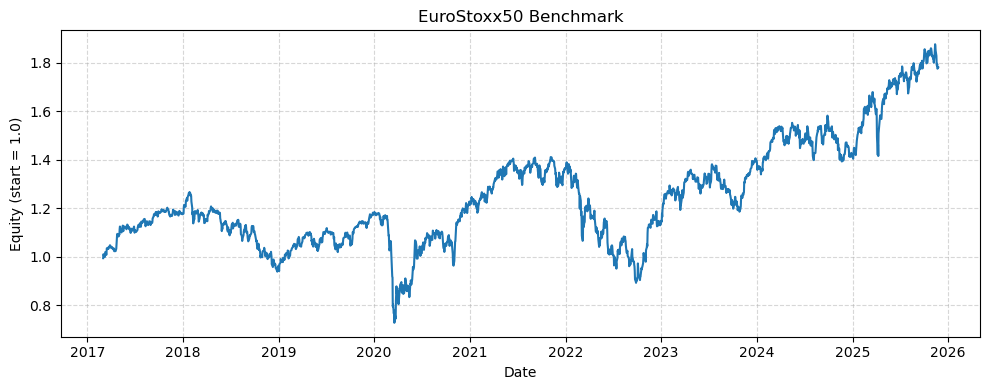

In [39]:
# choose your window
start = "2017-03-01"
end   = "2025-12-31"

bench_pnl = benchmark_returns(stoxx, start, end)

performance_summary(bench_pnl, periods_per_year=252)
plot_equity_curve(bench_pnl, title="EuroStoxx50 Benchmark")

## 1.4 Sector Data

In [40]:
tickers = close_df.columns

In [41]:
fields = [
    # company info
    "TR.CommonName",
    "TR.TickerSymbol",
    # TRBC hierarchy
    "TR.TRBCEconSectorCode",
    "TR.TRBCEconomicSector",
    "TR.TRBCBusinessSectorCode",
    "TR.TRBCBusinessSector",
    "TR.TRBCIndustryGroupCode",
    "TR.TRBCIndustryGroup",   # sometimes omitted, but you can request it
    "TR.TRBCIndustryCode",
    "TR.TRBCIndustry",
    "TR.TRBCActivityCode",
    "TR.TRBCActivity",
]

industries = rd.get_data(universe=tickers.to_list(),fields=fields)

In [42]:
industry = (
    industries
    .set_index("Instrument")["TRBC Industry Code"]   # or "TRBC Industry Group Code"
)

industry = industry.reindex(close_df.columns)

# Save

In [43]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install -U pyarrow pandas

  Using cached pandas-3.0.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached pandas-3.0.0-cp311-cp311-macosx_11_0_arm64.whl (9.9 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
refinitiv-data 1.6.2 requires pandas<3.0.0,>=1.3.5, but you have pandas 3.0.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [45]:
from pathlib import Path
import json

output_dir = Path('data/alpha_inputs')
output_dir.mkdir(parents=True, exist_ok=True)

dataframes = {
    'close_df': close_df,
    'returns_df': returns_df,
    'open_df': open_df,
    'high_df': high_df,
    'low_df': low_df,
    'volume_df': volume_df,
    'vwap_df': vwap_df,
    'revenue_df': revenue_df,
    'gross_profit_df': gross_profit_df,
    'EV_df': EV_df,
    'EBIT_df': EBIT_df,
    'EBITDA_df': EBITDA_df,
    'PE_df': PE_df,
    'WACC_df': WACC_df,
    'cap_df': cap_df,
    'debt_df': debt_df,
    'assets_df': assets_df,
    'liabilities_df': liabilities_df,
    'equity_df': equity_df,
    'sharesout_df': sharesout_df,
    'operating_income_df': operating_income_df,
}

manifest = {}
try:
    for name, df in dataframes.items():
        path = output_dir / f'{name}.parquet'
        df.to_parquet(path, index=True)
        manifest[name] = str(path)
    fmt = 'parquet'
except Exception as exc:
    print(f'Parquet save failed: {exc}\nFalling back to pickle.')
    for name, df in dataframes.items():
        path = output_dir / f'{name}.pkl'
        df.to_pickle(path)
        manifest[name] = str(path)
    fmt = 'pickle'

manifest_path = output_dir / 'manifest.json'
manifest_path.write_text(json.dumps({'format': fmt, 'files': manifest}, indent=2))


1216